📊 Aperçu des données :
  type_attack  impact  data_loss  frequency criticality
0    phishing     low          0          5         low
1     malware    high          1         10    critical
2        ddos  medium          0          7      medium
3    phishing  medium          1          6      medium
4     malware    high          1         12    critical

✅ Accuracy : 0.5

📊 Rapport de classification :
               precision    recall  f1-score   support

           0       0.50      1.00      0.67         1
           1       0.00      0.00      0.00         1

    accuracy                           0.50         2
   macro avg       0.25      0.50      0.33         2
weighted avg       0.25      0.50      0.33         2



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


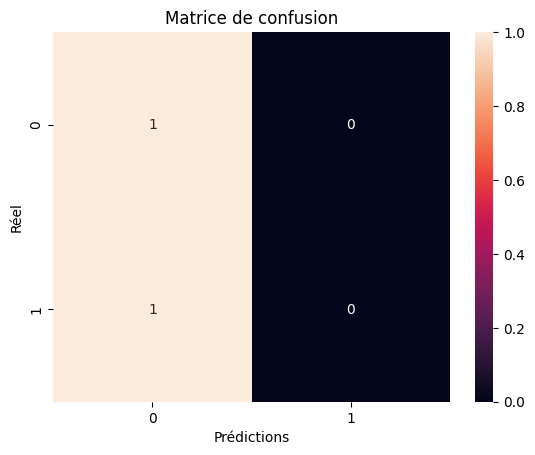


🔎 Niveau de criticité prédit : [3]


In [ ]:
# ============================================
# 📌 PROJET : Classification des incidents de cybersécurité
# ============================================

# 1️⃣ Installation des bibliothèques (si nécessaire)
!pip install pandas scikit-learn matplotlib seaborn

# 2️⃣ Importation des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# 3️⃣ Création d’un dataset simulé (exemple)
data = {
    "type_attack": ["phishing", "malware", "ddos", "phishing", "malware", "ddos", "phishing", "malware"],
    "impact": ["low", "high", "medium", "medium", "high", "high", "low", "medium"],
    "data_loss": [0, 1, 0, 1, 1, 1, 0, 0],
    "frequency": [5, 10, 7, 6, 12, 15, 3, 8],
    "criticality": ["low", "critical", "medium", "medium", "critical", "high", "low", "medium"]
}

df = pd.DataFrame(data)

print("📊 Aperçu des données :")
print(df.head())

# 4️⃣ Encodage des variables catégorielles
le = LabelEncoder()

for col in ["type_attack", "impact", "criticality"]:
    df[col] = le.fit_transform(df[col])

# 5️⃣ Séparation des features et target
X = df.drop("criticality", axis=1)
y = df["criticality"]

# 6️⃣ Division en train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 7️⃣ Entraînement du modèle
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 8️⃣ Prédictions
y_pred = model.predict(X_test)

# 9️⃣ Évaluation du modèle
print("\n✅ Accuracy :", accuracy_score(y_test, y_pred))
print("\n📊 Rapport de classification :\n", classification_report(y_test, y_pred))

# 🔟 Matrice de confusion
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True)
plt.title("Matrice de confusion")
plt.xlabel("Prédictions")
plt.ylabel("Réel")
plt.show()

# 1️⃣1️⃣ Test avec une nouvelle donnée
new_incident = pd.DataFrame({
    "type_attack": [0],   # phishing (après encodage)
    "impact": [1],        # medium
    "data_loss": [1],
    "frequency": [9]
})

prediction = model.predict(new_incident)

print("\n🔎 Niveau de criticité prédit :", prediction)